# Benchmarking Kmeans++ on Iris dataset and anisotropically distributed clusters

Adjusted Rand Index (iris): 0.7302, Silhouette Score (iris): 0.5528
Adjusted Rand Index (blobs): 0.9507, Silhouette Score (blobs): 0.6309


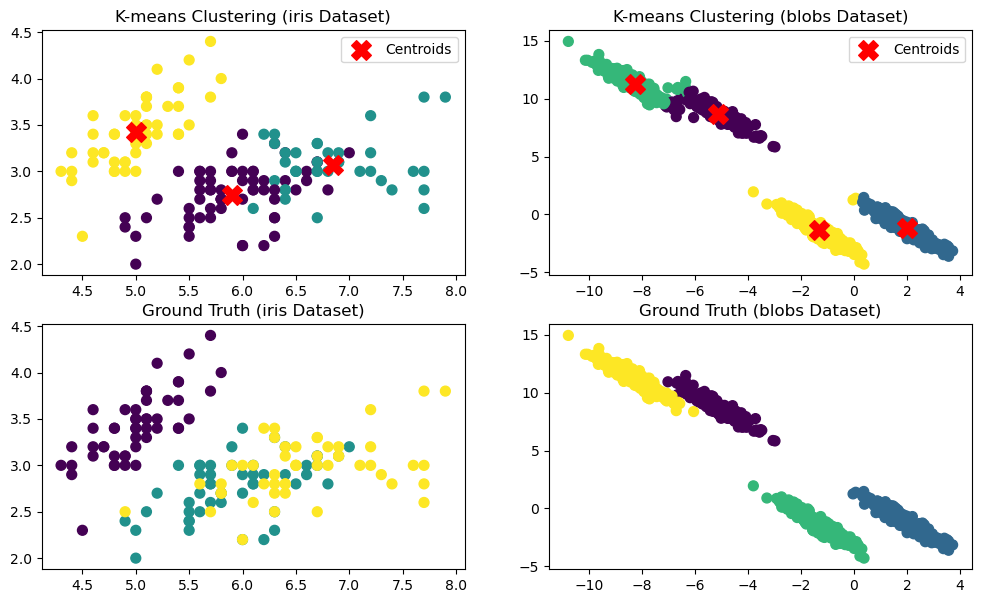

In [7]:
from sklearn.datasets import load_iris, make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
from kmeans import k_means


iris = load_iris()
X_iris, y_iris = iris.data, iris.target
kmeans_iris = k_means(K=3, method='kmeans++', max_iter=1000, tol=1e-4).fit(X_iris)

X_raw, y_blobs = make_blobs(
    n_samples=1000, centers=4,  random_state=42
)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_blobs = np.dot(X_raw, transformation)
kmeans_blobs = k_means(K=4, method='kmeans++', max_iter=1000, tol=1e-4).fit(X_blobs)


datasets = [('iris', X_iris, y_iris, kmeans_iris), ('blobs', X_blobs, y_blobs, kmeans_blobs)]


fig, ax = plt.subplots(2, 2, figsize=(12, 7))

for i, (name, x, y, model) in enumerate(datasets):
    ari = adjusted_rand_score(y, model.labels)
    sil = silhouette_score(x, model.labels)
    print(f"Adjusted Rand Index ({name}): {ari:.4f}, Silhouette Score ({name}): {sil:.4f}")

    ax[0, i].scatter(x[:, 0], x[:, 1], c=model.labels, cmap='viridis', s=50)
    ax[0, i].scatter(model.centroids[:, 0],  model.centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    ax[0, i].set_title(f'K-means Clustering ({name} Dataset)')
    ax[0, i].legend()

    ax[1, i].scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', s=50)
    ax[1, i].set_title(f'Ground Truth ({name} Dataset)')

    
plt.show()

# Benchmarking Gaussian Mixture Models (using Expectation Maximization Algorithm) on Iris dataset and anisotropically distributed clusters

iris | GaussianMixture | Adjusted Rand Index : 0.9039, Silhouette Score : 0.5012
blobs | GaussianMixture | Adjusted Rand Index : 0.9973, Silhouette Score : 0.6187


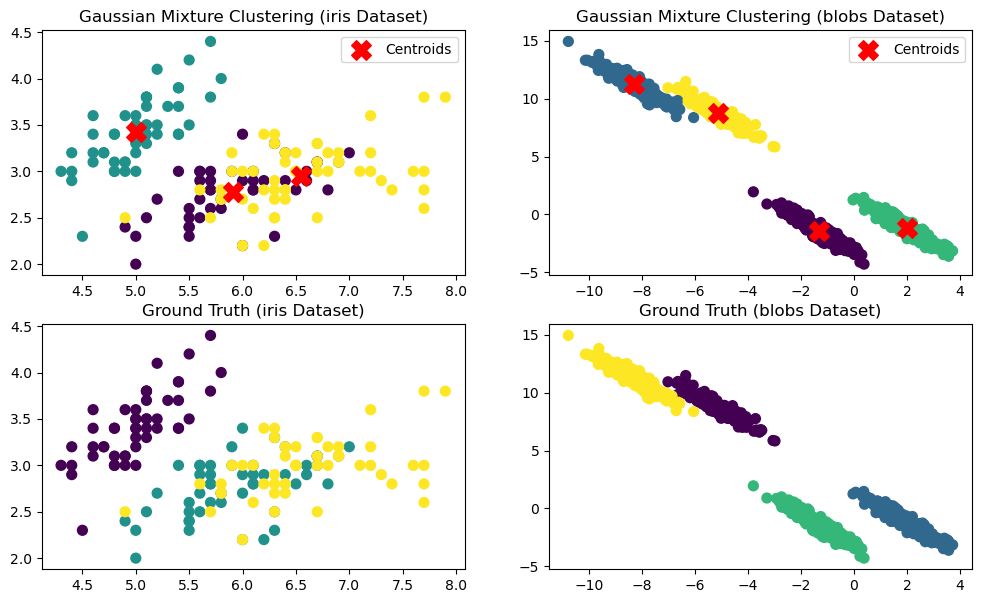

In [8]:
from sklearn.datasets import load_iris, make_blobs
from sklearn.metrics import adjusted_rand_score, silhouette_score
import matplotlib.pyplot as plt
from gmm import GaussianMixture
import numpy as np


iris = load_iris()
X_iris, y_iris = iris.data, iris.target
gmm_iris = GaussianMixture(K=3).fit(X_iris, max_iter=1000, tol=1e-4)

X_raw, y_blobs = make_blobs(
    n_samples=1000, centers=4,  cluster_std=1.0, random_state=42
)
transformation = np.array([[0.6, -0.6], [-0.4, 0.8]])
X_blobs = np.dot(X_raw, transformation)

gmm_blobs = GaussianMixture(K=4).fit(X_blobs, max_iter=1000, tol=1e-4)




datasets = [('iris', X_iris, y_iris, gmm_iris), ('blobs', X_blobs, y_blobs, gmm_blobs)]


fig, ax = plt.subplots(2, 2, figsize=(12, 7))

for i, (name, x, y, model) in enumerate(datasets):
    gmm_labels = model.predict(x)
    ari = adjusted_rand_score(y, gmm_labels)
    sil = silhouette_score(x, gmm_labels)
    print(f"{name} | GaussianMixture | Adjusted Rand Index : {ari:.4f}, Silhouette Score : {sil:.4f}")

    ax[0, i].scatter(x[:, 0], x[:, 1], c=gmm_labels, cmap='viridis', s=50)
    ax[0, i].scatter(model.means[:, 0],  model.means[:, 1], c='red', marker='X', s=200, label='Centroids')
    ax[0, i].set_title(f'Gaussian Mixture Clustering ({name} Dataset)')
    ax[0, i].legend()

    ax[1, i].scatter(x[:, 0], x[:, 1], c=y, cmap='viridis', s=50)
    ax[1, i].set_title(f'Ground Truth ({name} Dataset)')

    
plt.show()